In [1]:
from pathlib import Path
import requests

DATA_PATH = Path("data")
PATH = DATA_PATH / "mnist"

PATH.mkdir(parents=True, exist_ok=True)

URL = "https://github.com/pytorch/tutorials/raw/main/_static/"
FILENAME = "mnist.pkl.gz"

if not (PATH / FILENAME).exists():
  content = requests.get(URL + FILENAME).content
  (PATH / FILENAME).open("wb").write(content)

In [2]:
import pickle
import gzip

with gzip.open((PATH / FILENAME).as_posix(), "rb") as f:
  ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding="latin-1")

(50000, 784)


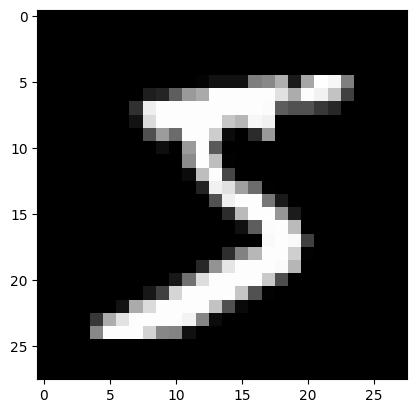

In [3]:
import matplotlib.pyplot as plt
import numpy as np

plt.imshow(x_train[0].reshape(28, 28), cmap='gray')
try:
  import google.colab
except ImportError:
  plt.show()
print(x_train.shape)

In [4]:
import torch

# mapping numpy values to torch tensors
x_train, y_train, x_valid, y_valid = map(
    torch.tensor, (x_train, y_train, x_valid, y_valid)
)

n, c = x_train.shape
print(x_train, y_train)
print(x_train.shape)
print(y_train.min(), y_train.max())

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]) tensor([5, 0, 4,  ..., 8, 4, 8])
torch.Size([50000, 784])
tensor(0) tensor(9)


In [5]:
import math

# Xavier initialisation (multiply by 1/sqrt(n))
weights = torch.randn(size=(784, 10)) / math.sqrt(784)
weights.requires_grad_() # we do not want random initialization tracked in gradient
bias = torch.zeros(size=(10,), requires_grad=True)

In [6]:
def log_softmax(x):
  return x - x.exp().sum(-1).log().unsqueeze(-1)

def model(xb):
  return log_softmax(torch.matmul(xb, weights) + bias)

In [7]:
bs = 64

xb = x_train[0:bs]
preds = model(xb)
preds[0], preds.shape
print(preds[0], preds.shape)

tensor([-2.1870, -1.8298, -2.6380, -3.0646, -1.9988, -2.5592, -2.3958, -2.6575,
        -2.0230, -2.2752], grad_fn=<SelectBackward0>) torch.Size([64, 10])


In [8]:
def nll(input, target):
  return -input[range(target.shape[0]), target].mean()

loss_func = nll

In [9]:
yb = y_train[0:bs]

print(loss_func(preds, yb))

tensor(2.3141, grad_fn=<NegBackward0>)


In [10]:
def accuracy(out, yb):
  preds = torch.argmax(out, dim=1)
  return (preds == yb).float().mean()

In [11]:
print(accuracy(preds, yb))

tensor(0.1562)


In [12]:
lr = 0.5
epochs = 2

for epoch in range(epochs):
  for i in range((n-1) // bs + 1):
    start_i = i * bs
    end_i = start_i + bs
    xb = x_train[start_i:end_i]
    yb = y_train[start_i:end_i]
    preds = model(xb)
    loss = loss_func(preds, yb)

    loss.backward()
    with torch.no_grad():
      weights -= weights.grad * lr
      bias -= bias.grad * lr
      weights.grad.zero_()
      bias.grad.zero_()

In [13]:
print(loss_func(model(xb), yb), accuracy(model(xb), yb))

tensor(0.0808, grad_fn=<NegBackward0>) tensor(1.)


In [14]:
import torch.nn.functional as F

loss_func = F.cross_entropy

def model(xb):
  return torch.matmul(xb, weights) + bias

print(loss_func(model(xb), yb))

tensor(0.0808, grad_fn=<NllLossBackward0>)


In [15]:
import torch.nn as nn

class Mnist_Logistic(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(size=(784, 10)) / math.sqrt(784))
    self.bias = nn.Parameter(torch.zeros(size=(10,)))

  def forward(self, xb):
    return torch.matmul(xb, self.weights) + self.bias

In [16]:
model = Mnist_Logistic()

In [17]:
print(loss_func(model(xb), yb))

tensor(2.3531, grad_fn=<NllLossBackward0>)


In [18]:
def fit():
  for epoch in range(epochs):
    for i in range((n-1) // bs + 1):
      start_i = i * bs
      end_i = start_i + bs
      xb = x_train[start_i:end_i]
      yb = y_train[start_i:end_i]

      preds = model(xb)
      loss = loss_func(preds, yb)

      loss.backward()
      with torch.no_grad():
        for p in model.parameters(): p -= p.grad * lr
        model.zero_grad()

fit()

In [19]:
print(loss_func(model(xb), yb))

tensor(0.0809, grad_fn=<NllLossBackward0>)


In [20]:
class Mnist_Logistic(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_layer = nn.Linear(in_features=784, out_features=10)

  def forward(self, xb):
    return self.linear_layer(xb)

In [21]:
model = Mnist_Logistic()
print(loss_func(model(xb), yb))

tensor(2.3126, grad_fn=<NllLossBackward0>)


In [22]:
fit()
print(loss_func(model(xb), yb))

tensor(0.0805, grad_fn=<NllLossBackward0>)


In [23]:
from torch import optim

In [24]:
def get_model():
  model = Mnist_Logistic()
  return model, optim.SGD(params=model.parameters(), lr=lr)

model, opt = get_model()
print(loss_func(model(xb), yb))

for epoch in range(epochs):
  for i in range((n-1) // bs + 1):
    start_i = i * bs
    end_i = start_i + bs
    xb = x_train[start_i:end_i]
    yb = y_train[start_i:end_i]

    preds = model(xb)
    loss = loss_func(preds, yb)

    loss.backward()
    opt.step()
    opt.zero_grad()

print(loss_func(model(xb), yb))

tensor(2.3389, grad_fn=<NllLossBackward0>)
tensor(0.0816, grad_fn=<NllLossBackward0>)


In [25]:
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(x_train, y_train) # this stores Xi an yi as tuple

In [26]:
model, opt = get_model()

for epoch in range(epochs):
  for i in range((n-1) // bs + 1):
    xb, yb = train_dataset[i*bs:i*bs+bs]
    preds = model(xb)
    loss = loss_func(preds, yb)

    loss.backward()
    opt.step()
    opt.zero_grad()

print(loss_func(model(xb), yb))

tensor(0.0812, grad_fn=<NllLossBackward0>)


In [27]:
from torch.utils.data import DataLoader

train_ds = TensorDataset(x_train, y_train)
train_dl = DataLoader(train_ds, batch_size=bs)

In [28]:
model, opt = get_model()

for epoch in range(epochs):
  for xb, yb in train_dl:
    preds = model(xb)
    loss = loss_func(preds, yb)

    loss.backward()
    opt.step()
    opt.zero_grad()

print(loss_func(model(xb), yb))

tensor(0.0827, grad_fn=<NllLossBackward0>)


In [29]:
train_ds = TensorDataset(x_train, y_train)
train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True)

valid_ds = TensorDataset(x_valid, y_valid)
valid_dl = DataLoader(valid_ds, batch_size=bs*2) # we use 2x larger bs as we are not storing gradients in eval so we can evaluate faster

In [30]:
model, opt = get_model()

for epoch in range(epochs):
  model.train()
  for xb, yb in train_dl:
    preds = model(xb)
    loss = loss_func(preds, yb)

    loss.backward()
    opt.step()
    opt.zero_grad()

  model.eval()
  with torch.no_grad():
     valid_loss = sum(loss_func(model(xb), yb) for xb, yb in valid_dl)

  print(epoch, valid_loss / len(valid_dl))


0 tensor(0.2886)
1 tensor(0.2901)


In [31]:
def loss_batch(model, loss_func, xb, yb, opt=None):
  if opt is not None:
    loss = loss_func(model(xb), yb)
    loss.backward()
    opt.step()
    opt.zero_grad()
  else:
    with torch.no_grad():
      loss = loss_func(model(xb), yb)
  return loss.item(), len(xb)

In [32]:
import numpy as np

def fit(epochs, model, loss_func, opt, train_dl, valid_dl):
  for epoch in range(epochs):
    model.train()
    for xb, yb in train_dl:
      loss_batch(model, loss_func, xb, yb, opt)

    model.eval()
    with torch.no_grad():
      losses, nums = zip(
        *[loss_batch(model, loss_func, xb, yb) for xb, yb in valid_dl]
      )
    val_loss = np.sum(np.multiply(losses, nums)) / np.sum(nums)

    print(epoch, val_loss)

In [33]:
def get_data(train_ds, valid_ds, bs):
  return(
      DataLoader(train_ds, batch_size=bs, shuffle=True),
      DataLoader(valid_ds, batch_size=bs*2)
  )

In [34]:
train_dl, valid_dl = get_data(train_ds, valid_ds, bs)
model, opt = get_model()
fit(epochs, model, loss_func, opt, train_dl, valid_dl)

0 0.36737379348278043
1 0.2971023828268051


In [35]:
class Mnist_CNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=2, padding=1)
    self.conv2 = nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, stride=2, padding=1)
    self.conv3 = nn.Conv2d(in_channels=16, out_channels=10, kernel_size=3, stride=2, padding=1)

  def forward(self, xb):
    xb = xb.view(-1, 1, 28, 28)
    xb = F.relu(self.conv1(xb))
    xb = F.relu(self.conv2(xb))
    xb = F.relu(self.conv3(xb))
    xb = F.avg_pool2d(xb, 4)
    return xb.view(-1, xb.size(1))

In [36]:
model = Mnist_CNN()
opt = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

In [37]:
fit(epochs, model, loss_func, opt, train_dl, valid_dl)

0 0.353500736361742
1 0.2424908429503441


In [38]:
class Lambda(nn.Module): # used to run preprocess inside Sequential block
  def __init__(self, func):
    super().__init__()
    self.func = func

  def forward(self, x):
    return self.func(x)

def preprocess(x):
  return x.view(-1, 1, 28, 28)

In [39]:
model = nn.Sequential(
    Lambda(preprocess),
    nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=2, padding=1),
    nn.ReLU(),
    nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, stride=2, padding=1),
    nn.ReLU(),
    nn.Conv2d(in_channels=16, out_channels=10, kernel_size=3, stride=2, padding=1),
    nn.ReLU(),
    nn.AvgPool2d(4),
    Lambda(lambda x: x.view(x.size(0), -1)),
)

opt = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

fit(epochs, model, loss_func, opt, train_dl, valid_dl)

0 0.38808258457183836
1 0.25138075936436655


In [40]:
def preprocess(x, y):
    return x.view(-1, 1, 28, 28), y

class WrappedDataLoader:
  def __init__(self, dl ,func):
    self.dl = dl
    self.func = func

  def __len__(self):
        return len(self.dl)

  def __iter__(self):
      for b in self.dl:
          yield (self.func(*b))

train_dl, valid_dl = get_data(train_ds, valid_ds, bs)
train_dl = WrappedDataLoader(train_dl, preprocess)
valid_dl = WrappedDataLoader(valid_dl, preprocess)

In [41]:
model = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
    nn.ReLU(),
    nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1),
    nn.ReLU(),
    nn.Conv2d(16, 10, kernel_size=3, stride=2, padding=1),
    nn.ReLU(),
    nn.AdaptiveAvgPool2d(1),
    Lambda(lambda x: x.view(x.size(0), -1)),
)

opt = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

In [42]:
fit(epochs, model, loss_func, opt, train_dl, valid_dl)

0 0.7974516379356384
1 0.7016313704967498
